dataset loaded successfully
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
Data Cleaned!


C:\Users\Pratham\AppData\Local\Temp\ipykernel_8444\2907999469.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class', y='survived', data=df, palette='viridis')


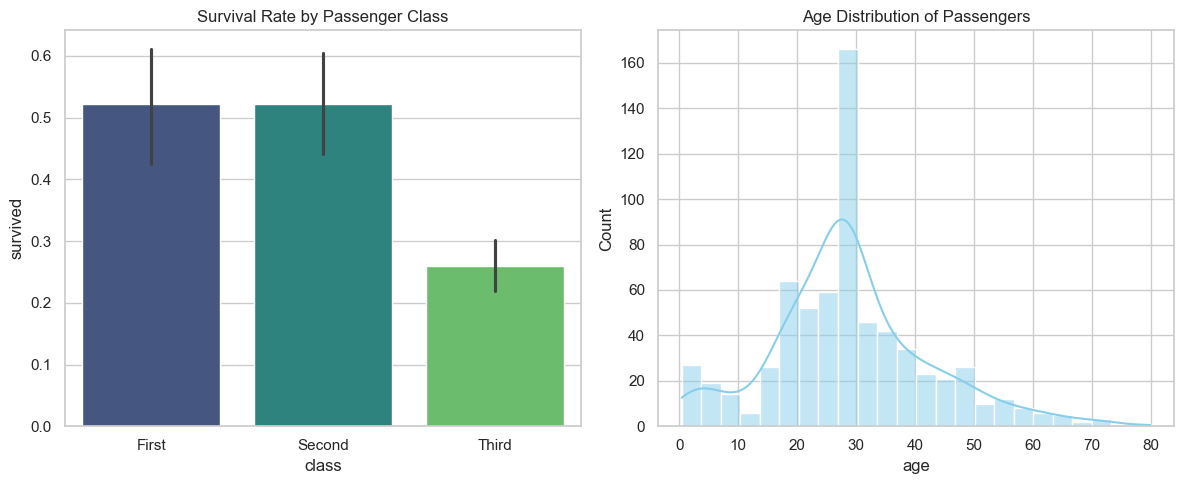

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df =sns.load_dataset('titanic')
print("dataset loaded successfully")
df.head()

# Check for missing values
print(df.isnull().sum())

# Handle missing values: Fill 'age' with the median, drop 'deck' (too many missing)
df['age'] = df['age'].fillna(df['age'].median())
df.drop(columns=['deck'], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

print("Data Cleaned!")


# Simple IQR method to filter outliers in 'fare'
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the data
df = df[(df['fare'] >= lower_bound) & (df['fare'] <= upper_bound)]


# Set the style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
plt.figure(figsize=(12, 5))

# Plot 1: Survival Rate by Class
plt.subplot(1, 2, 1)
sns.barplot(x='class', y='survived', data=df, palette='viridis')
plt.title('Survival Rate by Passenger Class')

# Plot 2: Age Distribution
plt.subplot(1, 2, 2)
sns.histplot(df['age'], kde=True, color='skyblue')
plt.title('Age Distribution of Passengers')

plt.tight_layout()
plt.show()